# Тема 6. Конструирование и отбор признаков

## Занятие 6 (теория)

**За пять занятий мы поднимали точность, меняя модель**: ручное правило (85.8%) → логрегрессия (86.5%) → дерево (93-94%) → лес (95.1%). Есть и другой рычаг — **не менять модель, а дать ей признаки получше**. Иногда одна новая колонка (или удаление лишней) даёт больше, чем смена алгоритма.

**План занятия:** масштабирование и логарифмирование → пропуски: ещё один приём → признаки из текста (Bag of Words/TF-IDF) → признаки из даты и координат → отбор признаков (статистический, модельный, Lasso).

**Практика** — в `lesson06_feature_engineering_practice.ipynb` (Titanic: новые признаки из имени и билета — помогут ли модели?).
**Дополнительно** (полный пример TF-IDF на реальных текстах, Sequential Feature Selection) — в `lesson06_feature_engineering_advanced.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import cross_val_score

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Масштабирование и логарифмирование

Мы уже масштабировали признаки перед kNN (тема 3) и логистической регрессией (тема 4), но не перед деревом решений (темы 3, 5). Это не случайность: дерево сравнивает признак **сам с собой** (`x > порог`), масштаб не влияет на результат сравнения. А kNN считает **расстояния между признаками**, а линейная модель **складывает** признаки с коэффициентами — там единицы измерения должны быть сопоставимы.

**Логарифмирование** — отдельный приём для признаков с сильно скошенным распределением (вспомним `Total intl calls` из темы 2 — там мы это заметили на гистограмме, но не трогали):

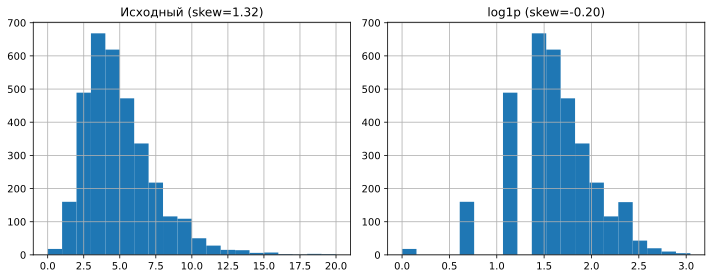

In [2]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)

_, axes = plt.subplots(1, 2, figsize=(10, 4))
df["Total intl calls"].hist(ax=axes[0], bins=20)
axes[0].set_title(f"Исходный (skew={df['Total intl calls'].skew():.2f})")
np.log1p(df["Total intl calls"]).hist(ax=axes[1], bins=20)
axes[1].set_title(f"log1p (skew={np.log1p(df['Total intl calls']).skew():.2f})")
plt.tight_layout();

`np.log1p` (это $\log(1+x)$, а не просто $\log(x)$ — переживает нули без ошибки) заметно приблизило распределение к симметричному. Для линейных моделей это часто помогает; для деревьев — почти не влияет, монотонное преобразование не меняет порядок значений, а дерево смотрит только на порядок.

---
## 2. Пропуски: ещё один приём

В теме 1 мы заполняли пропуски медианой/модой или выбрасывали строки. Есть третий вариант, который часто добавляет сигнал, а не только чинит данные: **колонка-индикатор** `was_missing` (1, если значение было пропущено). Сам факт пропуска иногда информативен — например, если `Age` не заполнен чаще у пассажиров с дешёвыми билетами (не было ресурсов записать точно), это уже намёк модели.

```python
data["Age_was_missing"] = data["Age"].isna().astype(int)
data["Age"] = data["Age"].fillna(data["Age"].median())
```

Применим на практике к `Age` в Titanic.

---
## 3. Признаки из текста: Bag of Words и TF-IDF

Модели нужны числа, а не строки. **Bag of Words (BoW)** — самый простой способ: считаем, сколько раз каждое слово встречается в каждом документе. Порядок слов теряется полностью (отсюда «мешок»), но для многих задач (например, тональность отзыва) этого достаточно.

In [3]:
texts = [
    "клиент недоволен качеством связи",
    "клиент доволен новым тарифом",
    "качеством связи недоволен новый клиент",
]

bow = CountVectorizer()
X_bow = bow.fit_transform(texts)
pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out())

,доволен,качеством,клиент,недоволен,новый,новым,связи,тарифом
0,0,1,1,1,0,0,1,0
1,1,0,1,0,0,1,0,1
2,0,1,1,1,1,0,1,0


Проблема BoW: частые, но малоинформативные слова (в русском — предлоги, в любом языке — общеупотребимые термы) получают такой же вес, как редкие и содержательные. **TF-IDF** (Term Frequency — Inverse Document Frequency) взвешивает слово обратно пропорционально тому, в скольких документах оно встречается — редкие, но характерные слова получают больший вес:

In [4]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(texts)
pd.DataFrame(X_tfidf.toarray().round(2), columns=tfidf.get_feature_names_out())

,доволен,качеством,клиент,недоволен,новый,новым,связи,тарифом
0,0.00,0.53,0.41,0.53,0.00,0.00,0.53,0.00
1,0.55,0.00,0.32,0.00,0.00,0.55,0.00,0.55
2,0.00,0.43,0.34,0.43,0.57,0.00,0.43,0.00


«клиент» встречается во всех трёх документах — его вес занижен и в BoW-нормировке (относительно длины документа), а тем более в TF-IDF. «доволен»/«недоволен» — более редкие и содержательные слова — получили больший вес. Полный пример на настоящих текстах — в `lesson06_feature_engineering_advanced.ipynb`.

---
## 4. Признаки из даты и времени

В `lesson01_pandas_advanced.ipynb` мы уже доставали `.dt.year`/`.dt.month`/`.dt.dayofweek` — этого часто достаточно. Один нюанс, который легко упустить: час `23` и час `0` для модели — это **далеко друг от друга числа** (разница 23), хотя по смыслу они соседние (полночь). Обычное решение — **циклическое кодирование** через синус/косинус, тогда 23 и 0 окажутся рядом и на числовой оси:

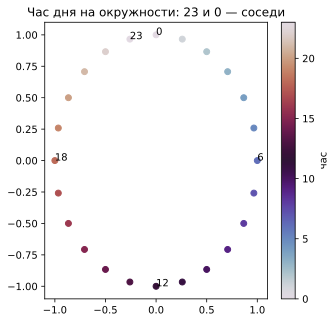

In [5]:
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

plt.figure(figsize=(5, 5))
plt.scatter(hour_sin, hour_cos, c=hours, cmap="twilight")
for h in [0, 6, 12, 18, 23]:
    plt.annotate(str(h), (hour_sin[h], hour_cos[h]))
plt.colorbar(label="час")
plt.title("Час дня на окружности: 23 и 0 — соседи");

---
## 5. Признаки из координат

Сырые широта/долгота редко полезны модели напрямую — важнее производные величины: расстояние до значимой точки (центр города, ближайший офис), принадлежность к региону/кластеру координат. Простой пример — расстояние до центра (формула гаверсинусов, учитывает кривизну Земли, в отличие от евклидова расстояния на градусах):

In [6]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

moscow_center = (55.7558, 37.6173)
points = pd.DataFrame({
    "name": ["Красная площадь", "Шереметьево", "Домодедово"],
    "lat": [55.7539, 55.9736, 55.4103],
    "lon": [37.6208, 37.4125, 37.9025],
})
points["dist_to_center_km"] = haversine_km(*moscow_center, points["lat"], points["lon"])
points

,name,lat,lon,dist_to_center_km
0,Красная площадь,55.7539,37.6208,0.304301
1,Шереметьево,55.9736,37.4125,27.382884
2,Домодедово,55.4103,37.9025,42.393493


Для координат также часто помогает кластеризация (объединить близкие точки в один категориальный признак «район») — к этому вернёмся в теме 7.

---
## 6. Отбор признаков

Больше признаков — не всегда лучше: лишние признаки замедляют обучение, могут вносить шум, а для линейных моделей — портить интерпретируемость (тема 4, история с `Total day minutes`/`charge`).

**Статистический отбор** — `SelectKBest`: для каждого признака отдельно считаем статистику связи с целевой (например, F-статистику) и берём топ-`k`, не обучая саму модель:

In [7]:
X = df.drop(columns=["State", "Churn"])
X["International plan"] = (df["International plan"] == "Yes").astype(int)
X["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)
y = df["Churn"]

skb = SelectKBest(f_classif, k=8).fit(X, y)
print("Топ-8 признаков по F-статистике:")
print(X.columns[skb.get_support()].tolist())

Топ-8 признаков по F-статистике:
['International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day charge', 'Total eve minutes', 'Total eve charge', 'Customer service calls']


**Модельный отбор** — `SelectFromModel`: обучаем модель (например, лес — у него уже есть `feature_importances_`) и оставляем только признаки важнее порога.

**Задание преподавателю на занятии:** обучите `SelectFromModel(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), threshold="median")` на `X`/`y`, посмотрите, сколько признаков осталось, сравните `cross_val_score` полного и урезанного наборов.

In [ ]:
# sfm = SelectFromModel(RandomForestClassifier(...), threshold="median").fit(X, y)
# X_reduced = sfm.transform(X)
# cross_val_score(RandomForestClassifier(...), X, y, cv=5).mean()
# cross_val_score(RandomForestClassifier(...), X_reduced, y, cv=5).mean()


Урезанный набор (в 2 раза меньше признаков) даёт точность чуть ниже полного — «медианный» порог здесь слишком агрессивен. Отбор признаков — это компромисс (простота/скорость/интерпретируемость против точности), а не гарантированное улучшение; порог стоит подбирать, а не брать по умолчанию.

**Lasso как встроенный отбор** — вспомним тему 4: L1-регуляризация обнуляет часть коэффициентов сама, по ходу обучения:

In [8]:
Xs = StandardScaler().fit_transform(X)
lasso = LogisticRegression(l1_ratio=1, solver="liblinear", C=0.1, random_state=RANDOM_STATE)
lasso.fit(Xs, y)

coefs = pd.Series(lasso.coef_[0], index=X.columns)
print("Обнулённые Lasso признаки:", coefs[coefs == 0].index.tolist())

Обнулённые Lasso признаки: ['Area code', 'Number vmail messages', 'Total eve calls', 'Total night calls', 'Total intl minutes']


Ровно тот же список, что мог бы дать `SelectFromModel`, но без отдельного шага — отбор происходит одновременно с обучением модели.

---
## Итог занятия

Сегодня разобрали:

- Когда масштабирование обязательно (kNN, линейные модели), а когда нет (деревья, леса)
- Логарифмирование скошенных признаков
- Индикатор пропуска как отдельный признак
- Bag of Words / TF-IDF для текста
- Циклическое кодирование времени, признаки из координат
- `SelectKBest`, `SelectFromModel`, Lasso как встроенный отбор

**Дальше:**
- Практика — `lesson06_feature_engineering_practice.ipynb` (Titanic: новые признаки — помогут ли?)
- Доп. материалы — `lesson06_feature_engineering_advanced.ipynb`
- Следующее занятие — обучение без учителя: PCA и кластеризация